In [38]:
# Evaluation utilities for manuscript text line detection and segmentation
import numpy as np
from typing import List, Tuple, Dict
from shapely.geometry import Polygon

    # For standalone usage
def match_score(mask_gt, mask_pred):
    inter = np.logical_and(mask_gt, mask_pred).sum()
    union = np.logical_or(mask_gt, mask_pred).sum()
    if union == 0:
        return 0.0
    return inter / union

def hscp_polygon_eval(gt_xml: str, pred_xml: str, page_height: int, page_width: int,
                     iou_thresh: float = 0.75) -> Dict[str, float]:
    """
    Evaluate polygon predictions using Detection Rate (DR), Recognition Accuracy (RA), and F-Measure (FM).
    
    Args:
        gt_xml: Path to ground truth XML
        pred_xml: Path to prediction XML
        page_height, page_width: Page dimensions
        iou_thresh: IoU threshold for matching
    
    Returns:
        Dictionary with DR, RA, FM, M (matches), N_gt, N_pred
    """
    from .xml_utils import parse_xml_polygons
    
    gt_polys = parse_xml_polygons(gt_xml)
    pred_polys = parse_xml_polygons(pred_xml)
    
    N1 = len(gt_polys)     # GT lines
    N2 = len(pred_polys)   # Pred lines
    
    if N1 == 0 or N2 == 0:
        return {
            "DR": 0.0,
            "RA": 0.0,
            "FM": 0.0,
            "M": 0,
            "N_gt": N1,
            "N_pred": N2
        }
    
    gt_masks = [
        polygon_to_mask(p, page_height, page_width)
        for p in gt_polys
    ]
    pred_masks = [
        polygon_to_mask(p, page_height, page_width)
        for p in pred_polys
    ]
    
    used_gt = set()
    used_pred = set()
    M = 0
    
    # Greedy one-to-one matching
    for i, gt_mask in enumerate(gt_masks):
        best_j = -1
        best_score = 0.0
        
        for j, pr_mask in enumerate(pred_masks):
            if j in used_pred:
                continue
            score = match_score(gt_mask, pr_mask)
            if score > best_score:
                best_score = score
                best_j = j
        
        if best_score >= iou_thresh and best_j >= 0:
            M += 1
            used_gt.add(i)
            used_pred.add(best_j)
    
    DR = M / N1 if N1 > 0 else 0.0
    RA = M / N2 if N2 > 0 else 0.0
    FM = (2 * DR * RA) / (DR + RA) if (DR + RA) > 0 else 0.0
    
    return {
        "DR": round(DR, 2),
        "RA": round(RA, 2),
        "FM": round(FM, 2),
        "M": M,
        "N_gt": N1,
        "N_pred": N2
    }

def calculate_iou_polygon(poly_a_coords: np.ndarray, poly_b_coords: np.ndarray) -> float:
    """
    Calculate IoU between two polygons using Shapely.
    
    Args:
        poly_a_coords, poly_b_coords: Polygon coordinates
    
    Returns:
        IoU score between 0 and 1
    """
    try:
        a = Polygon(poly_a_coords)
        b = Polygon(poly_b_coords)
        if not a.is_valid: a = a.buffer(0)
        if not b.is_valid: b = b.buffer(0)
        intersection = a.intersection(b).area
        union = a.union(b).area
        return intersection / union if union > 0 else 0.0
    except:
        return 0.0

def hscp_pixel_eval(gt_mask: np.ndarray, pred_mask: np.ndarray,
                   iou_thresh: float = 0.75) -> Dict[str, float]:
    """
    Evaluate pixel-level predictions using connected components.
    
    Args:
        gt_mask: Ground truth binary mask
        pred_mask: Predicted binary mask
        iou_thresh: IoU threshold for matching components
    
    Returns:
        Dictionary with DR, RA, FM, M (matches), N_gt, N_pred
    """
    import cv2
    
    # Find connected components in GT mask
    gt_num_labels, gt_labels = cv2.connectedComponents(gt_mask.astype(np.uint8))
    
    # Find connected components in predicted mask
    pred_num_labels, pred_labels = cv2.connectedComponents(pred_mask.astype(np.uint8))
    
    N_gt = gt_num_labels - 1  # Exclude background (label 0)
    N_pred = pred_num_labels - 1  # Exclude background (label 0)
    
    if N_gt == 0 or N_pred == 0:
        return {
            "DR": 0.0,
            "RA": 0.0,
            "FM": 0.0,
            "M": 0,
            "N_gt": N_gt,
            "N_pred": N_pred
        }
    
    # Create individual component masks
    gt_component_masks = []
    for i in range(1, gt_num_labels):  # Skip background
        component_mask = (gt_labels == i).astype(np.uint8)
        gt_component_masks.append(component_mask)
    
    pred_component_masks = []
    for i in range(1, pred_num_labels):  # Skip background
        component_mask = (pred_labels == i).astype(np.uint8)
        pred_component_masks.append(component_mask)
    
    # Match components using greedy approach
    used_gt = set()
    used_pred = set()
    M = 0
    
    for i, gt_comp_mask in enumerate(gt_component_masks):
        best_j = -1
        best_score = 0.0
        
        for j, pred_comp_mask in enumerate(pred_component_masks):
            if j in used_pred:
                continue
            score = match_score(gt_comp_mask, pred_comp_mask)
            if score > best_score:
                best_score = score
                best_j = j
        
        if best_score >= iou_thresh and best_j >= 0:
            M += 1
            used_gt.add(i)
            used_pred.add(best_j)
    
    DR = M / N_gt if N_gt > 0 else 0.0
    RA = M / N_pred if N_pred > 0 else 0.0
    FM = (2 * DR * RA) / (DR + RA) if (DR + RA) > 0 else 0.0
    
    return {
        "DR": round(DR, 2),
        "RA": round(RA, 2),
        "FM": round(FM, 2),
        "M": M,
        "N_gt": N_gt,
        "N_pred": N_pred
    }

TRAIN_IMG_DIR = "../00_data/DIVA-HisDB/CB55/img-CB55/img/training/"
TRAIN_XML_DIR = "../00_data/DIVA-HisDB/CB55/PAGE-gt-CB55/PAGE-gt/training/"

VAL_IMG_DIR = "../00_data/DIVA-HisDB/CB55/img-CB55/img/validation/"
VAL_XML_DIR = "../00_data/DIVA-HisDB/CB55/PAGE-gt-CB55/PAGE-gt/validation/"

TEST_IMG_DIR = "../00_data/DIVA-HisDB/CB55/img-CB55/img/public-test/"
TEST_XML_DIR = "../00_data/DIVA-HisDB/CB55/PAGE-gt-CB55/PAGE-gt/public-test/"

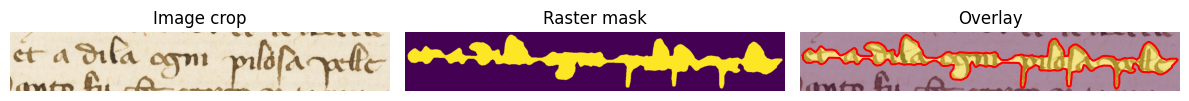

In [39]:
# Dataset creation + visualization of one bbox with rasterized polygon mask

import os
import random
import xml.etree.ElementTree as ET
import cv2
import torch
from torch.utils.data import Dataset
import numpy as np
import matplotlib.pyplot as plt

def parse_xml_polygons(xml_path):
    ns = {"ns": "http://schema.primaresearch.org/PAGE/gts/pagecontent/2013-07-15"}
    tree = ET.parse(xml_path)
    root = tree.getroot()
    polygons = []

    for tl in root.findall(".//ns:TextLine", ns):
        coords = tl.find("ns:Coords", ns)
        if coords is None:
            continue
        pts = []
        for xy in coords.attrib["points"].split():
            x, y = map(int, xy.split(","))
            pts.append((x, y))
        polygons.append(pts)

    return polygons

def polygon_to_bbox(poly):
    xs = [p[0] for p in poly]
    ys = [p[1] for p in poly]
    return min(xs), min(ys), max(xs), max(ys)

class TextLineSegDataset(Dataset):
    def __init__(self, img_dir, xml_dir, pad=10):
        self.samples = []
        self.pad = pad

        for fname in os.listdir(img_dir):
            if not fname.endswith(".jpg") and not fname.endswith(".png"):
                continue

            img_path = os.path.join(img_dir, fname)
            xml_path = os.path.join(xml_dir, fname.replace(".jpg", ".xml").replace(".png", ".xml"))

            if not os.path.exists(xml_path):
                continue

            polygons = parse_xml_polygons(xml_path)
            for poly in polygons:
                bbox = polygon_to_bbox(poly)
                self.samples.append((img_path, poly, bbox))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, poly, bbox = self.samples[idx]
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        h, w, _ = img.shape
        x1, y1, x2, y2 = bbox

        x1 = max(0, x1 - self.pad)
        y1 = max(0, y1 - self.pad)
        x2 = min(w, x2 + self.pad)
        y2 = min(h, y2 + self.pad)

        crop = img[y1:y2, x1:x2]

        mask = np.zeros((y2 - y1, x2 - x1), dtype=np.uint8)
        poly_shifted = np.array(poly) - np.array([x1, y1])
        cv2.fillPoly(mask, [poly_shifted.astype(np.int32)], 1)

        crop = torch.tensor(crop / 255.0).permute(2, 0, 1).float()
        mask = torch.tensor(mask).unsqueeze(0).float()

        return crop, mask, poly_shifted

# --- Visualize one sample ---

dataset = TextLineSegDataset(TRAIN_IMG_DIR, TRAIN_XML_DIR)

idx = random.randint(0, len(dataset) - 1)
img, mask, poly = dataset[idx]

img_np = img.permute(1, 2, 0).numpy()
mask_np = mask.squeeze().numpy()

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.title("Image crop")
plt.imshow(img_np)
plt.axis("off")

plt.subplot(1, 3, 2)
plt.title("Raster mask")
plt.imshow(mask_np)
plt.axis("off")

plt.subplot(1, 3, 3)
plt.title("Overlay")
plt.imshow(img_np)
plt.imshow(mask_np, alpha=0.4)
plt.plot(poly[:, 0], poly[:, 1], "-r")
plt.axis("off")

plt.tight_layout()
plt.show()


In [ ]:
widths = []
heights = []
for img_path, poly, bbox in dataset.samples:
    x1, y1, x2, y2 = bbox
    widths.append(x2 - x1)
    heights.append(y2 - y1)

print(f"Width: min={min(widths)}, max={max(widths)}, mean={np.mean(widths):.2f}, std={np.std(widths):.2f}")
print(f"Height: min={min(heights)}, max={max(heights)}, mean={np.mean(heights):.2f}, std={np.std(heights):.2f}")

print(f"Width: p20={np.percentile(widths, 20):.2f}, p80={np.percentile(widths, 80):.2f}")
print(f"Height: p20={np.percentile(heights, 20):.2f}, p80={np.percentile(heights, 80):.2f}")

print(f"Width: p5={np.percentile(widths, 5):.2f}, p95={np.percentile(widths, 95):.2f}")
print(f"Height: p5={np.percentile(heights, 5):.2f}, p95={np.percentile(heights, 95):.2f}")

Width: min=31, max=4136, mean=1398.14, std=715.13
Height: min=48, max=286, mean=161.21, std=38.71
Width: p20=861.00, p80=1884.00
Height: p20=126.00, p80=200.00
Width: p5=766.30, p95=2890.40
Height: p5=110.00, p95=222.00


In [41]:
class TextLineSegDataset(torch.utils.data.Dataset):
    def __init__(self, img_dir, xml_dir, pad=5, resize=None):
        self.samples = []
        self.pad = pad
        self.resize = resize

        for fname in sorted(os.listdir(img_dir)):
            if not fname.lower().endswith((".jpg", ".png", ".tif")):
                continue

            img_path = os.path.join(img_dir, fname)
            xml_path = os.path.join(
                xml_dir,
                os.path.splitext(fname)[0] + ".xml"
            )

            if not os.path.exists(xml_path):
                continue

            polygons = self.parse_xml_polygons(xml_path)
            for poly in polygons:
                bbox = self.polygon_to_bbox(poly)
                self.samples.append((img_path, poly, bbox))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, poly, bbox = self.samples[idx]

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        H, W, _ = img.shape

        x1, y1, x2, y2 = bbox
        x1 = max(0, x1 - self.pad)
        y1 = max(0, y1 - self.pad)
        x2 = min(W, x2 + self.pad)
        y2 = min(H, y2 + self.pad)

        crop = img[y1:y2, x1:x2]
        mask = np.zeros((y2 - y1, x2 - x1), dtype=np.uint8)

        poly_shifted = np.array(poly) - np.array([x1, y1])
        cv2.fillPoly(mask, [poly_shifted.astype(np.int32)], 1)

        if self.resize is not None:
            crop = cv2.resize(crop, self.resize)
            mask = cv2.resize(mask, self.resize, interpolation=cv2.INTER_NEAREST)

        crop = torch.from_numpy(crop).permute(2, 0, 1).float() / 255.0
        mask = torch.from_numpy(mask).unsqueeze(0).float()

        return crop, mask

    @staticmethod
    def parse_xml_polygons(xml_path):
        ns = {"ns": "http://schema.primaresearch.org/PAGE/gts/pagecontent/2013-07-15"}
        tree = ET.parse(xml_path)
        root = tree.getroot()

        polygons = []
        for tl in root.findall(".//ns:TextLine", ns):
            coords = tl.find("ns:Coords", ns)
            if coords is None:
                continue
            pts = [(int(x), int(y)) for x, y in
                   (p.split(",") for p in coords.attrib["points"].split())]
            polygons.append(pts)
        return polygons

    @staticmethod
    def polygon_to_bbox(poly):
        xs = [p[0] for p in poly]
        ys = [p[1] for p in poly]
        return min(xs), min(ys), max(xs), max(ys)


In [42]:
RESIZE = (256, 256)
BATCH_SIZE = 8

train_ds = TextLineSegDataset(
    TRAIN_IMG_DIR, TRAIN_XML_DIR,
    pad=15, resize=RESIZE
)

val_ds = TextLineSegDataset(
    VAL_IMG_DIR, VAL_XML_DIR,
    pad=15, resize=RESIZE
)

test_ds = TextLineSegDataset(
    TEST_IMG_DIR, TEST_XML_DIR,
    pad=15, resize=RESIZE
)

train_loader = torch.utils.data.DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=4
)

val_loader = torch.utils.data.DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=4
)

print(f"Train samples: {len(train_ds)}")
print(f"Validation samples: {len(val_ds)}")
print(f"Test samples: {len(test_ds)}")


Train samples: 1507
Validation samples: 901
Test samples: 845


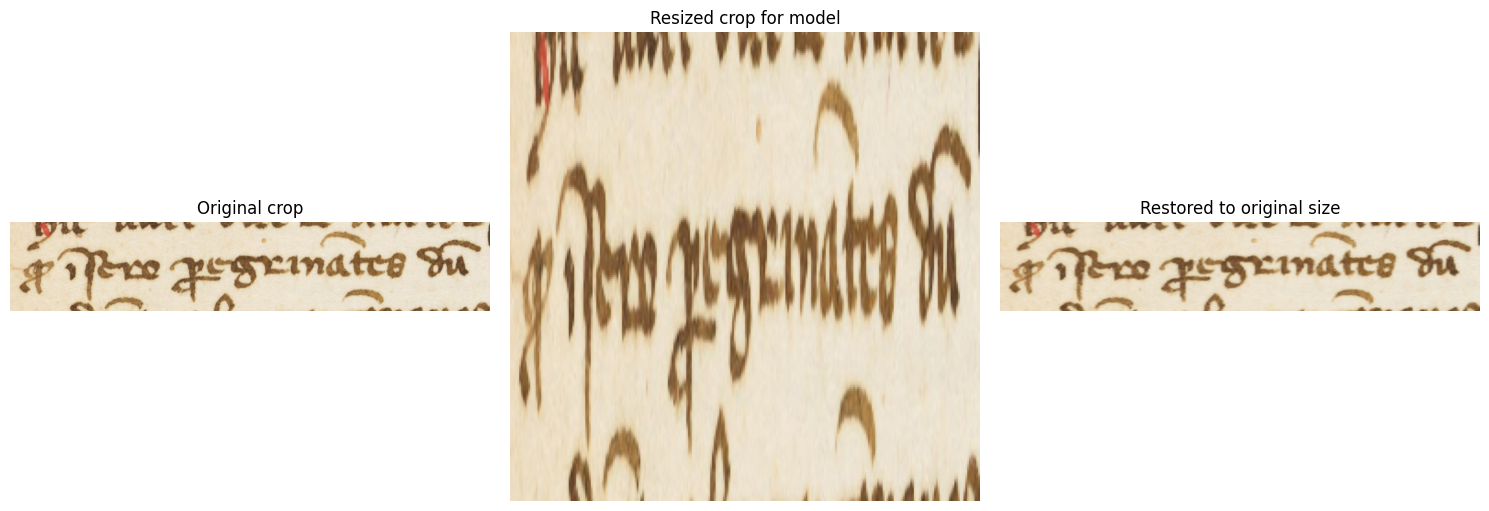

In [43]:
# случайный индекс
idx = random.randint(0, len(TEST_IMG_DIR)-1)

test_ds_orig = TextLineSegDataset(
    TEST_IMG_DIR, TEST_XML_DIR, pad=15, resize=None
)

# --- оригинальный crop ---
crop_orig, mask_orig = test_ds_orig[idx]    
crop_orig_np = crop_orig.permute(1,2,0).numpy()
orig_h, orig_w = crop_orig_np.shape[:2]

# --- сжатый crop для модели ---
crop_resized, mask_resized = test_ds[idx]

crop_resized_np = crop_resized.permute(1,2,0).numpy()

# --- восстановленный в оригинальный размер ---
crop_restored = cv2.resize(crop_resized_np, (orig_w, orig_h), interpolation=cv2.INTER_LINEAR)

# --- визуализация ---
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.title("Original crop")
plt.imshow(crop_orig_np)
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Resized crop for model")
plt.imshow(crop_resized_np)
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Restored to original size")
plt.imshow(crop_restored)
plt.axis("off")

plt.tight_layout()
plt.show()


In [ ]:
import segmentation_models_pytorch as smp

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

model = smp.Unet(
    encoder_name="resnet18",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
    # decoder_channels=(256, 128, 64, 32, 16),
    decoder_dropout=0.2
).to(DEVICE)

print("Model created and moved to device:", DEVICE)

Model created and moved to device: cuda


In [34]:
bce = torch.nn.BCEWithLogitsLoss()

def dice_loss(logits, targets, eps=1e-6):
    probs = torch.sigmoid(logits)
    inter = (probs * targets).sum(dim=(2,3))
    union = probs.sum(dim=(2,3)) + targets.sum(dim=(2,3))
    dice = (2 * inter + eps) / (union + eps)
    return 1 - dice.mean()

def loss_fn(logits, targets):
    return 0.5 * bce(logits, targets) + 0.5 * dice_loss(logits, targets)


In [ ]:
def otsu_batch(probs: torch.Tensor) -> torch.Tensor:
    """
    probs: (B, 1, H, W), float in [0, 1]
    returns: (B, 1, H, W), binary mask
    """
    probs_np = probs.detach().cpu().numpy()[:, 0]  # (B, H, W)

    bin_masks = np.zeros_like(probs_np, dtype=np.uint8)

    for i in range(probs_np.shape[0]):
        p = (probs_np[i] * 255).astype(np.uint8)
        _, bin_masks[i] = cv2.threshold(
            p, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
        )

    bin_masks = torch.from_numpy(bin_masks).unsqueeze(1)
    return bin_masks.to(probs.device).float() / 255.0

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)
EPOCHS = 5

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0

    for imgs, masks in train_loader:
        imgs = imgs.to(DEVICE)
        masks = masks.to(DEVICE)

        logits = model(imgs)
        loss = loss_fn(logits, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    model.eval()
    val_dice = 0.0
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs = imgs.to(DEVICE)
            masks = masks.to(DEVICE)

            logits = model(imgs)
            probs = torch.sigmoid(logits)

            bin_masks = otsu_batch(probs)

            inter = (bin_masks * masks).sum(dim=(2,3))
            union = bin_masks.sum(dim=(2,3)) + masks.sum(dim=(2,3))
            dice = (2 * inter + 1e-6) / (union + 1e-6)

            val_dice += dice.mean().item()

    val_dice /= len(val_loader)

    print(f"Epoch {epoch:02d} | train_loss={train_loss/len(train_loader):.4f} | val_dice={val_dice:.4f}")

torch.save(model.state_dict(), "unet_diva_segm.pth")


Epoch 00 | train_loss=0.1777 | val_dice=0.9208
Epoch 01 | train_loss=0.1150 | val_dice=0.9116
Epoch 02 | train_loss=0.0972 | val_dice=0.9360
Epoch 03 | train_loss=0.0918 | val_dice=0.9440
Epoch 04 | train_loss=0.0866 | val_dice=0.9446


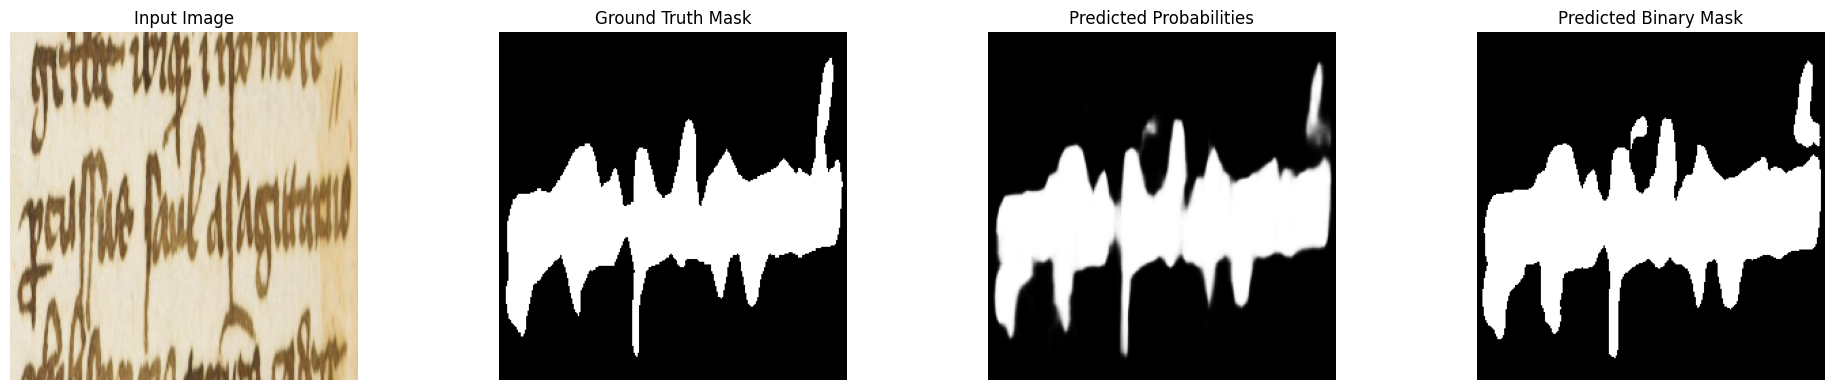

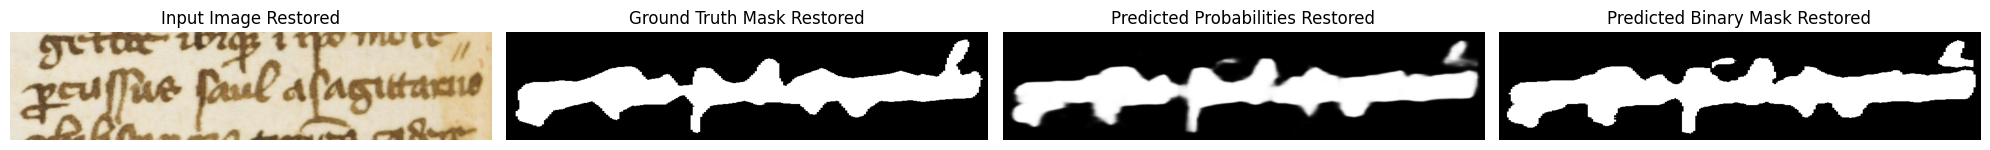

In [46]:
import cv2
import numpy as np
import random
import matplotlib.pyplot as plt
import torch # Ensure torch is imported

# Assuming test_ds, model, and DEVICE are defined elsewhere in your code
idx = random.randint(0, len(test_ds) - 1)
img, mask = test_ds[idx]

img_input = img.unsqueeze(0).to(DEVICE)

with torch.no_grad():
    logits = model(img_input)
    probs = torch.sigmoid(logits)[0, 0].cpu().numpy()

# hard thresholding at 0.5
pred_bin = (probs >= 0.1).astype(np.uint8)

img_np = img.permute(1, 2, 0).cpu().numpy()
gt_mask = mask[0].cpu().numpy()

# plot input image, gt mask, predicted prob map, predicted binary mask
# on second figure plot everything transformed back to original size
plt.figure(figsize=(20, 4))
plt.subplot(1, 4, 1)
plt.title("Input Image")
plt.imshow(img_np)
plt.axis("off")
plt.subplot(1, 4, 2)
plt.title("Ground Truth Mask")
plt.imshow(gt_mask, cmap="gray")
plt.axis("off")
plt.subplot(1, 4, 3)
plt.title("Predicted Probabilities")
plt.imshow(probs, cmap="gray")
plt.axis("off")
plt.subplot(1, 4, 4)
plt.title("Predicted Binary Mask")
plt.imshow(pred_bin, cmap="gray")
plt.axis("off")
plt.tight_layout()
plt.show()

orinal_h, original_w = test_ds_orig[idx][0].permute(1,2,0).shape[:2]
plt.figure(figsize=(20, 4))
plt.subplot(1, 4, 1)
plt.title("Input Image Restored")
plt.imshow(cv2.resize(img_np, (original_w, orinal_h), interpolation=cv2.INTER_LINEAR))
plt.axis("off")
plt.subplot(1, 4, 2)
plt.title("Ground Truth Mask Restored")
plt.imshow(cv2.resize(gt_mask, (original_w, orinal_h), interpolation=cv2.INTER_NEAREST), cmap="gray")
plt.axis("off")
plt.subplot(1, 4, 3)
plt.title("Predicted Probabilities Restored")
plt.imshow(cv2.resize(probs, (original_w, orinal_h), interpolation=cv2.INTER_LINEAR), cmap="gray")
plt.axis("off")
plt.subplot(1, 4, 4)
plt.title("Predicted Binary Mask Restored")
plt.imshow(cv2.resize(pred_bin, (original_w, orinal_h), interpolation=cv2.INTER_NEAREST), cmap="gray")
plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
from tqdm import tqdm
ious = []

for idx in tqdm(range(len(test_ds))):
    img, mask = test_ds[idx]
    img_input = img.unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        logits = model(img_input)
        probs = torch.sigmoid(logits)[0, 0].cpu().numpy()

    # hard thresholding at 0.5
    pred_bin = (probs >= 0.1).astype(np.uint8)

    # restore to original size
    orig_h, orig_w = test_ds_orig[idx][0].permute(1,2,0).shape[:2]
    pred_bin_restored = cv2.resize(pred_bin, (orig_w, orig_h), interpolation=cv2.INTER_NEAREST)
    gt_mask_restored = test_ds_orig[idx][1][0].cpu().numpy()

    # compute IoU
    inter = np.logical_and(pred_bin_restored, gt_mask_restored).sum()
    union = np.logical_or(pred_bin_restored, gt_mask_restored).sum()
    iou = inter / (union + 1e-6)
    ious.append(iou)

mean_iou = np.mean(ious)
print(f"Mean IoU on test set: {mean_iou:.4f}")

  0%|          | 0/845 [00:00<?, ?it/s]

100%|██████████| 845/845 [05:33<00:00,  2.54it/s]

Mean IoU on test set: 0.8558
